In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image
from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
DATASET_ROOT = '/content/drive/MyDrive/FruitinAmazon/FruitinAmazon'

train_dir = os.path.join(DATASET_ROOT, 'train')
test_dir  = os.path.join(DATASET_ROOT, 'test')

assert os.path.isdir(train_dir), f"train_dir not found: {train_dir}"

Task 1: Data Understanding and Visualization:


### 1a. Visualise one random image per class

Classes (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


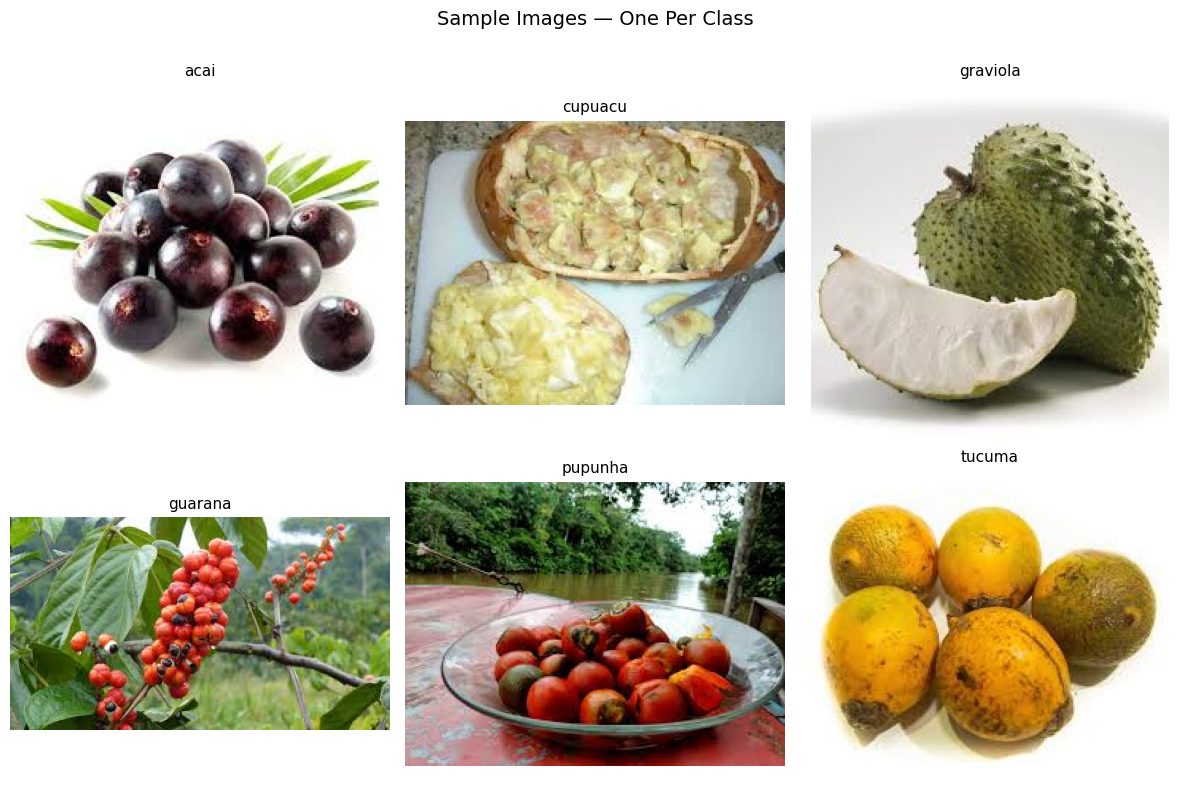


Observation: Images vary significantly in background, lighting, and scale across classes. Normalisation and augmentation will be important.


In [4]:
# get sorted list of class directories
class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])
num_classes = len(class_dirs)
print(f"Classes ({num_classes}):", class_dirs)

# pick one random image per class
random.seed(42)
sample_images = []
sample_labels = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    files = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    if files:
        chosen = random.choice(files)
        sample_images.append(os.path.join(cls_path, chosen))
        sample_labels.append(cls)

# display in a 2-row grid
cols = (num_classes + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(cols * 4, 8))
axes = axes.flatten()

for i, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = Image.open(img_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=11)
    axes[i].axis('off')

# hide any unused subplots
for j in range(len(sample_images), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images — One Per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nObservation: Images vary significantly in background, lighting, "
      "and scale across classes. Normalisation and augmentation will be important.")

### 1b. Check for and remove corrupted images

In [5]:
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        try:
            with Image.open(fpath) as img:
                img.verify()
        except (IOError, SyntaxError):
            corrupted.append(fpath)
            os.remove(fpath)
            print(f"Removed corrupted image: {fpath}")

if not corrupted:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted)}")

No corrupted images found.


## Task 2 — Load and Preprocess Data with Keras

In [6]:

IMG_HEIGHT      = 128
IMG_WIDTH       = 128
BATCH_SIZE      = 32
VALIDATION_SPLIT = 0.2
SEED            = 123

rescale = tf.keras.layers.Rescaling(1.0 / 255)

# Training split
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation split
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Test dataset
if os.path.isdir(test_dir):
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        interpolation='nearest',
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    test_ds = test_ds.map(lambda x, y: (rescale(x), y))
    print("Using separate test directory.")
else:
    test_ds = val_ds
    print("No separate test directory found — using validation split as test set.")

# cache & prefetch for performance
#AUTOTUNE = tf.data.AUTOTUNE
#train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
#val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
#test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(f"\nnum_classes = {num_classes}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Using separate test directory.

num_classes = 6


## Task 3 — Build the CNN

In [7]:
def build_model(input_shape=(128, 128, 3), num_classes=6):
    """
W    Conv(32, 3x3, same, stride=1) → ReLU → MaxPool(2x2, stride=2)
    Conv(32, 3x3, same, stride=1) → ReLU → MaxPool(2x2, stride=2)
    Flatten → Dense(128) → Dense(64) → Dense(num_classes, softmax)
    """
    model = keras.Sequential([
        # Input
        layers.Input(shape=input_shape),

        # Conv Block 1
        layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same',
                      strides=(1, 1), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Conv Block 2
        layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same',
                      strides=(1, 1), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Fully Connected
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),

        # Output
        layers.Dense(num_classes, activation='softmax')
    ], name='CNN_Fruit_Classifier')

    return model

model = build_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=num_classes)
model.summary()

Model: "CNN_Fruit_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4 — Compile the Model

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")

Model compiled successfully.


## Task 4 — Train the Model (batch=16, epochs=250, callbacks)

In [10]:
# Callbacks
checkpoint_path = '/content/best_model.h5'

checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

train_ds_16 = train_ds.unbatch().batch(16)
val_ds_16   = val_ds.unbatch().batch(16)

history = model.fit(
    train_ds_16,
    epochs=250,
    validation_data=val_ds_16,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1
)

Epoch 1/250
      5/Unknown 8s 619ms/step - accuracy: 0.1740 - loss: 2.1727

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from None to 0.05556, saving model to /content/best_model.h5



Epoch 1: finished saving model to /content/best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 945ms/step - accuracy: 0.1667 - loss: 2.2145 - val_accuracy: 0.0556 - val_loss: 1.9783
Epoch 2/250
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4549 - loss: 1.6834 
Epoch 2: val_accuracy improved from 0.05556 to 0.11111, saving model to /content/best_model.h5



Epoch 2: finished saving model to /content/best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 378ms/step - accuracy: 0.3472 - loss: 1.7009 - val_accuracy: 0.1111 - val_loss: 1.8420
Epoch 3/250
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3785 - loss: 1.4465 
Epoch 3: val_accuracy improved from 0.11111 to 0.66667, saving model to /content/best_model.h5



Epoch 3: finished saving model to /content/best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.4583 - loss: 1.4287 - val_accuracy: 0.6667 - val_loss: 1.2308
Epoch 4/250
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.6875 - loss: 1.1287
Epoch 4: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7222 - loss: 0.9506 - val_accuracy: 0.5556 - val_loss: 1.0619
Epoch 5/250
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8576 - loss: 0.6317 
Epoch 5: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8333 - loss: 0.6439 - val_accuracy: 0.6667 - val_loss: 0.9701
Epoch 6/250
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8090 - loss: 0.5240 
Epoch 6: val_accuracy improved from 0.66667 to 0.83333, saving model to /content/best_model.h5



Epoch 6: finished saving model to /content/best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8750 - loss: 0.4022 - val_accuracy: 0.8333 - val_loss: 0.5226
Epoch 7/250
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9861 - loss: 0.1865 
Epoch 7: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9306 - loss: 0.2353 - val_accuracy: 0.8333 - val_loss: 0.5674
Epoch 8/250
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9826 - loss: 0.1161 
Epoch 8: val_accuracy improved from 0.83333 to 0.88889, saving model to /content/best_model.h5



Epoch 8: finished saving model to /content/best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9861 - loss: 0.1125 - val_accuracy: 0.8889 - val_loss: 0.3930
Epoch 9/250
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9618 - loss: 0.0821
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9861 - loss: 0.0656 - val_accuracy: 0.8333 - val_loss: 0.5314
Epoch 10/250
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0426 
Epoch 10: val_accuracy improved from 0.88889 to 0.94444, saving model to /content/best_model.h5



Epoch 10: finished saving model to /content/best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 367ms/step - accuracy: 1.0000 - loss: 0.0309 - val_accuracy: 0.9444 - val_loss: 0.2309
Epoch 11/250
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 1.0000 - loss: 0.0137 
Epoch 11: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 1.0000 - loss: 0.0151 - val_accuracy: 0.8889 - val_loss: 0.3373
Epoch 12/250
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 1.0000 - loss: 0.0114 
Epoch 12: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 0.8889 - val_loss: 0.5151
Epoch 13/250
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.0034 
Epoch 13: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.8889 - val_loss: 0.6664
Epoch 14/250
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 1.0000 

### Training Curves

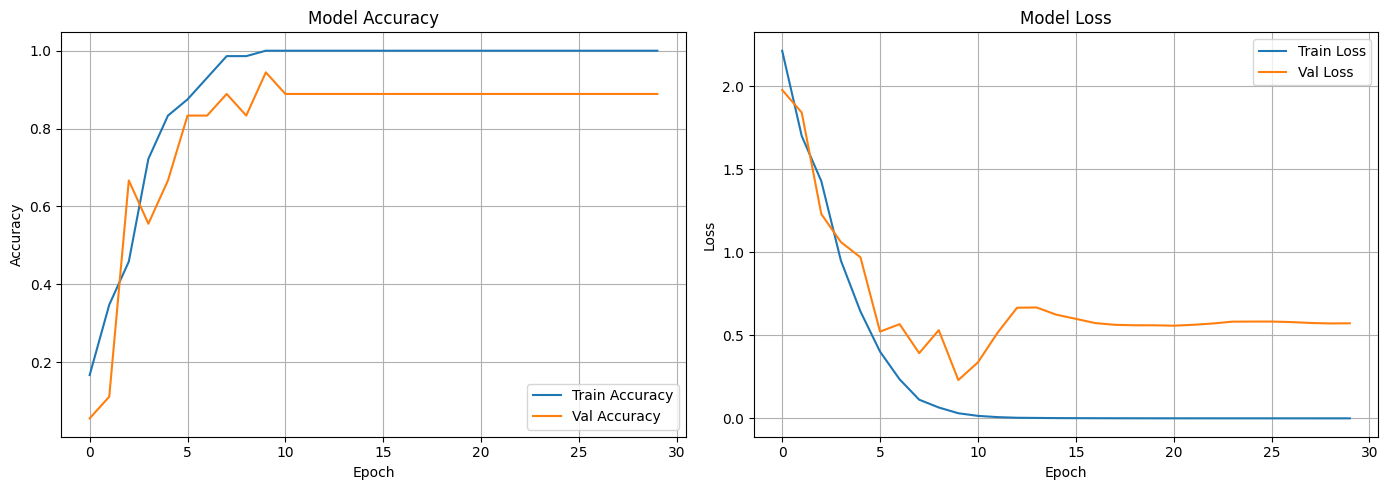

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

## Task 5 — Evaluate the Model

In [12]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.8000 - loss: 0.7703

Test Loss    : 0.7703
Test Accuracy: 0.8000


## Task 6 — Save and Load the Model

In [13]:
# Save
save_path = '/content/cnn_fruit_classifier.h5'
model.save(save_path)
print(f"Model saved to: {save_path}")

# Load and re-evaluate
loaded_model = keras.models.load_model(save_path)
print("\nRe-evaluating loaded model...")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"Loaded Model — Test Loss: {loaded_loss:.4f} | Test Accuracy: {loaded_acc:.4f}")

Model saved to: /content/cnn_fruit_classifier.h5

Re-evaluating loaded model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step - accuracy: 0.8000 - loss: 0.7703
Loaded Model — Test Loss: 0.7703 | Test Accuracy: 0.8000


## Task 7 — Predictions and Classification Report

In [14]:
# Collect all true labels and predictions from test_ds
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_dirs))


Classification Report:
              precision    recall  f1-score   support

        acai       0.83      1.00      0.91         5
     cupuacu       0.80      0.80      0.80         5
    graviola       0.71      1.00      0.83         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.71      1.00      0.83         5
      tucuma       1.00      0.20      0.33         5

    accuracy                           0.80        30
   macro avg       0.84      0.80      0.77        30
weighted avg       0.84      0.80      0.77        30



### Visualise Sample Predictions

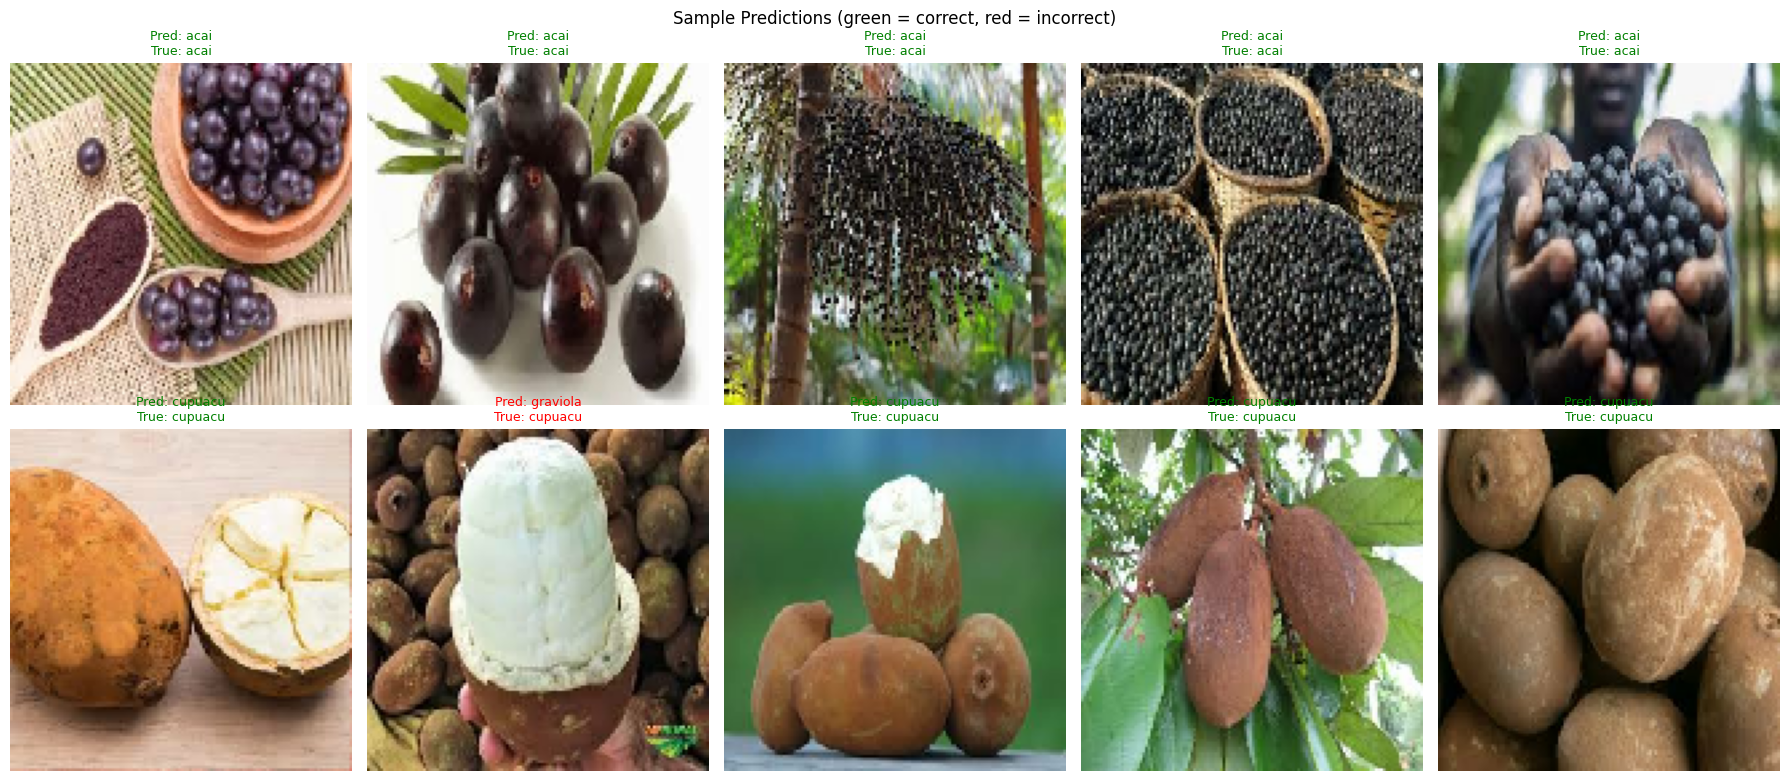

In [15]:
# Show first 10 test images with predicted vs actual label
sample_images_batch, sample_labels_batch = next(iter(test_ds))
sample_preds = np.argmax(loaded_model.predict(sample_images_batch, verbose=0), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(sample_images_batch[i].numpy())
    pred_label  = class_dirs[sample_preds[i]]
    true_label  = class_dirs[sample_labels_batch[i].numpy()]
    colour = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f"Pred: {pred_label}\nTrue: {true_label}",
                      color=colour, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Predictions (green = correct, red = incorrect)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/sample_predictions.png', dpi=150)
plt.show()